In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 2.8 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 3.1 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.5 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import yfinance as yf

# Download Reliance Industries stock data - last 6 months
stock = yf.download("RELIANCE.NS", period="6mo", interval="1d")

# Show the data
print(stock)

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2025-12-26  1552.024048  1553.815812  1547.146696  1547.544758     2311495
2025-12-29  1538.486694  1550.929166  1536.495899  1547.743942     5972105
2025-12-30  1532.713379  1546.449794  1530.722584  1539.880194     8815884
2025-12-31  1563.172607  1569.742208  1533.907890  1533.907890     5771830
2026-01-01  1568.348511  1585.170755  1563.869221  1566.457231     6408128
...                 ...          ...          ...          ...         ...
2026-06-19  1309.500000  1338.199951  1305.300049  1328.000000    24887034
2026-06-22  1326.500000  1344.900024  1314.099976  1316.699951    12931213
2026-06-23  1309.500000  1333.000000  1304.000000  1328.900024    15400184
2026-06-24  1313.599976  1322.000000  1297.500000  1305.699951    11030917
2026-06-25  1318.099976  

Matplotlib is building the font cache; this may take a moment.


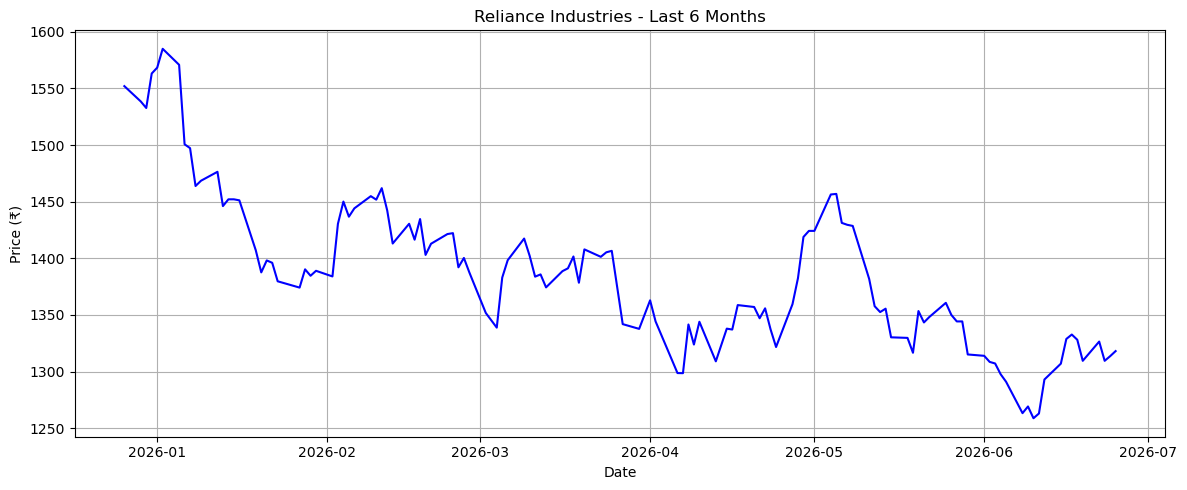

In [3]:
import matplotlib.pyplot as plt

# Plot closing price
plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], color='blue', linewidth=1.5)
plt.title('Reliance Industries - Last 6 Months')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.grid(True)
plt.tight_layout()
plt.show()

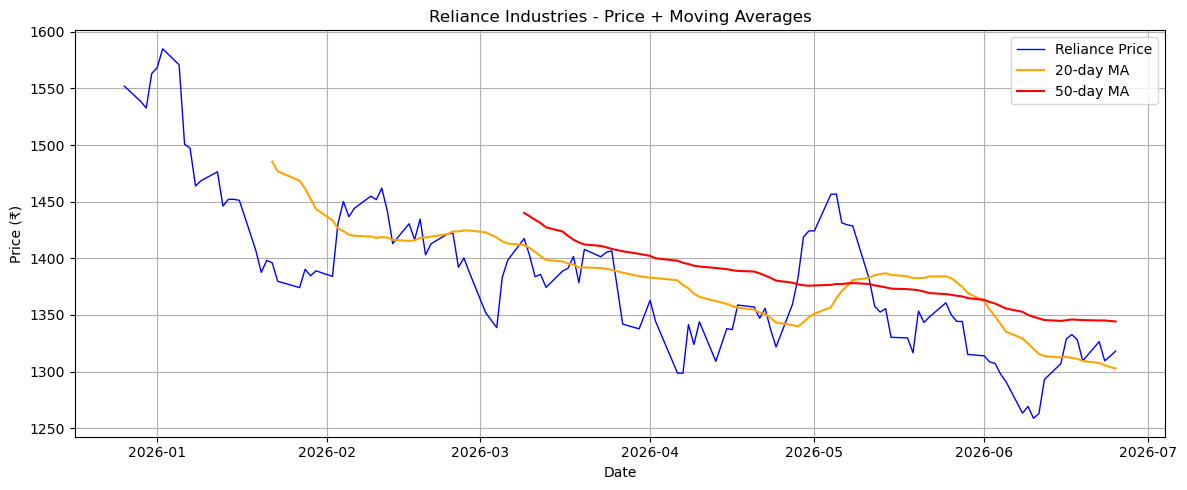

In [4]:
# Calculate Moving Averages
stock['MA20'] = stock['Close'].rolling(window=20).mean()  # 20-day average
stock['MA50'] = stock['Close'].rolling(window=50).mean()  # 50-day average

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], label='Reliance Price', color='blue', linewidth=1)
plt.plot(stock['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock['MA50'], label='50-day MA', color='red', linewidth=1.5)

plt.title('Reliance Industries - Price + Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

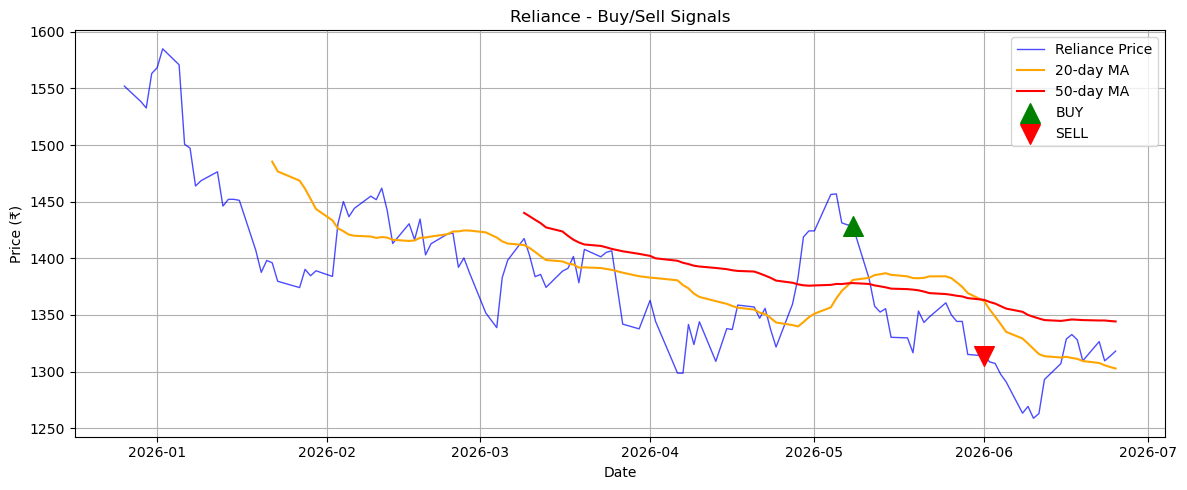


📈 BUY signals on:
Price             Close
Ticker      RELIANCE.NS
Date                   
2026-05-08  1428.594727

📉 SELL signals on:
Price             Close
Ticker      RELIANCE.NS
Date                   
2026-06-01  1313.924927


In [5]:
# Generate Buy/Sell Signals
stock['Signal'] = 0
stock.loc[stock['MA20'] > stock['MA50'], 'Signal'] = 1   # Buy signal
stock.loc[stock['MA20'] < stock['MA50'], 'Signal'] = -1  # Sell signal

# Detect crossover points
stock['Position'] = stock['Signal'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], label='Reliance Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock['MA50'], label='50-day MA', color='red', linewidth=1.5)

# Buy signals - green arrows
buy = stock[stock['Position'] == 2]
plt.scatter(buy.index, buy['Close'], marker='^', color='green', 
            label='BUY', s=200, zorder=5)

# Sell signals - red arrows
sell = stock[stock['Position'] == -2]
plt.scatter(sell.index, sell['Close'], marker='v', color='red', 
            label='SELL', s=200, zorder=5)

plt.title('Reliance - Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the signals
print("\n📈 BUY signals on:")
print(buy[['Close']].to_string())
print("\n📉 SELL signals on:")
print(sell[['Close']].to_string())

In [6]:
# Backtest
initial_capital = 100000  # ₹1 lakh starting money
capital = initial_capital
shares = 0
trades = []

for date, row in stock.iterrows():
    # BUY
    if row['Position'] == 2 and capital > 0:
        shares = capital // row['Close'].values[0]
        capital -= shares * row['Close'].values[0]
        trades.append({'Date': date, 'Action': 'BUY', 
                      'Price': row['Close'].values[0], 'Shares': shares})
    
    # SELL
    elif row['Position'] == -2 and shares > 0:
        capital += shares * row['Close'].values[0]
        trades.append({'Date': date, 'Action': 'SELL', 
                      'Price': row['Close'].values[0], 'Shares': shares})
        shares = 0

# Final value
final_value = capital + (shares * stock['Close'].iloc[-1].values[0])

print(f"Starting Capital: ₹{initial_capital:,.0f}")
print(f"Final Value:      ₹{final_value:,.0f}")
print(f"Profit/Loss:      ₹{final_value - initial_capital:,.0f}")
print(f"Return:           {((final_value - initial_capital)/initial_capital)*100:.2f}%")
print("\nTrades:")
for t in trades:
    print(f"{t['Date'].date()

SyntaxError: incomplete input (2098140625.py, line 31)

In [7]:
# Backtest
initial_capital = 100000  # ₹1 lakh starting money
capital = initial_capital
shares = 0
trades = []

for date, row in stock.iterrows():
    # BUY
    if row['Position'] == 2 and capital > 0:
        shares = capital // row['Close'].values[0]
        capital -= shares * row['Close'].values[0]
        trades.append({'Date': date, 'Action': 'BUY', 
                      'Price': row['Close'].values[0], 'Shares': shares})
    
    # SELL
    elif row['Position'] == -2 and shares > 0:
        capital += shares * row['Close'].values[0]
        trades.append({'Date': date, 'Action': 'SELL', 
                      'Price': row['Close'].values[0], 'Shares': shares})
        shares = 0

# Final value
final_value = capital + (shares * stock['Close'].iloc[-1].values[0])

print(f"Starting Capital: ₹{initial_capital:,.0f}")
print(f"Final Value:      ₹{final_value:,.0f}")
print(f"Profit/Loss:      ₹{final_value - initial_capital:,.0f}")
print(f"Return:           {((final_value - initial_capital)/initial_capital)*100:.2f}%")
print("\nTrades:")
for t in trades:
    print(f"{t['Date'].date()} | {t['Action']} | ₹{t['Price']:.0f} | {t['Shares']:.0f} shares")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [8]:
# Backtest - Fixed
initial_capital = 100000  # ₹1 lakh starting money
capital = initial_capital
shares = 0
trades = []

for date, row in stock.iterrows():
    position = row['Position'].item()
    close_price = row['Close'].item()
    
    # BUY
    if position == 2 and capital > 0:
        shares = capital // close_price
        capital -= shares * close_price
        trades.append({'Date': date, 'Action': 'BUY', 
                      'Price': close_price, 'Shares': shares})
    
    # SELL
    elif position == -2 and shares > 0:
        capital += shares * close_price
        trades.append({'Date': date, 'Action': 'SELL', 
                      'Price': close_price, 'Shares': shares})
        shares = 0

# Final value
final_close = stock['Close'].iloc[-1].item()
final_value = capital + (shares * final_close)

print(f"Starting Capital: ₹{initial_capital:,.0f}")
print(f"Final Value:      ₹{final_value:,.0f}")
print(f"Profit/Loss:      ₹{final_value - initial_capital:,.0f}")
print(f"Return:           {((final_value - initial_capital)/initial_capital)*100:.2f}%")
print("\nTrades:")
for t in trades:
    print(f"{t['Date'].date()} | {t['Action']} | ₹{t['Price']:.0f} | {t['Shares']:.0f} shares")

Starting Capital: ₹100,000
Final Value:      ₹92,088
Profit/Loss:      ₹-7,912
Return:           -7.91%

Trades:
2026-05-08 | BUY | ₹1429 | 69 shares
2026-06-01 | SELL | ₹1314 | 69 shares


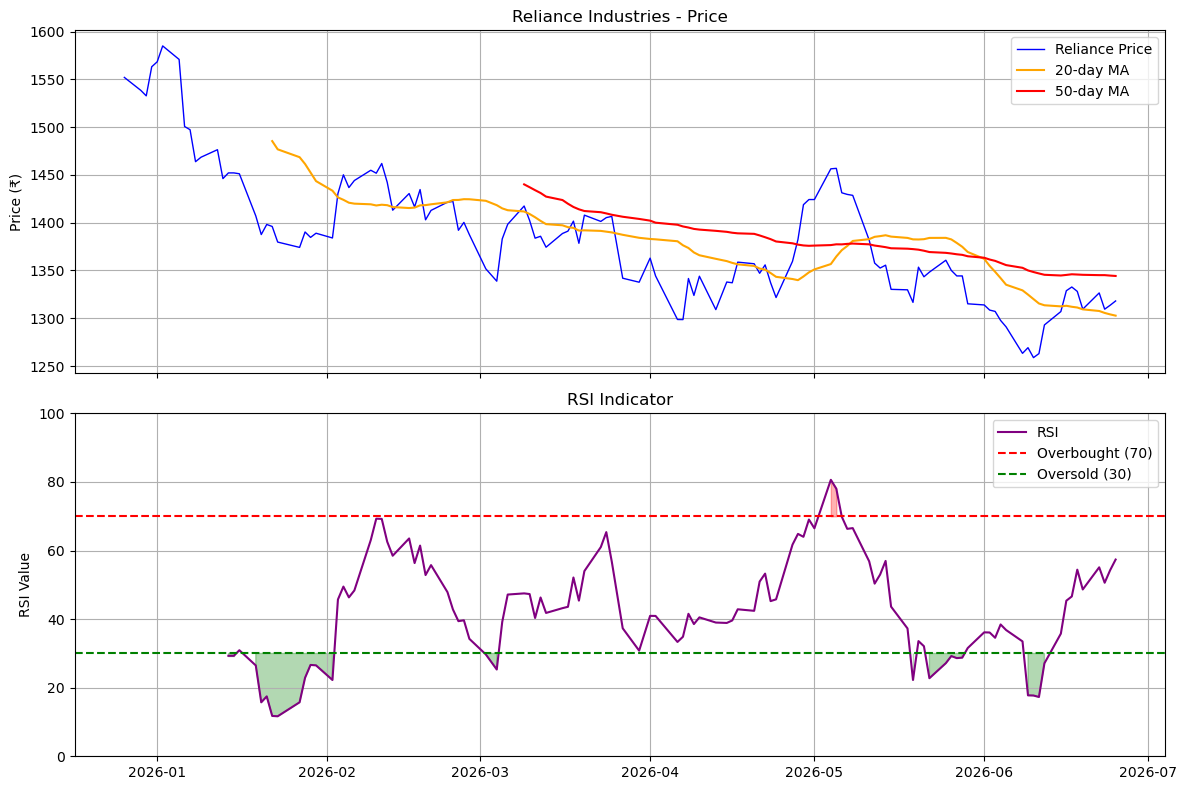


Current RSI: 57.38
Signal: NEUTRAL


In [9]:
# Calculate RSI
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stock['RSI'] = calculate_rsi(stock['Close'])

# Plot RSI
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Price chart on top
ax1.plot(stock['Close'], label='Reliance Price', color='blue', linewidth=1)
ax1.plot(stock['MA20'], label='20-day MA', color='orange', linewidth=1.5)
ax1.plot(stock['MA50'], label='50-day MA', color='red', linewidth=1.5)
ax1.set_title('Reliance Industries - Price')
ax1.set_ylabel('Price (₹)')
ax1.legend()
ax1.grid(True)

# RSI chart below
ax2.plot(stock['RSI'], label='RSI', color='purple', linewidth=1.5)
ax2.axhline(70, color='red', linestyle='--', label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', label='Oversold (30)')
ax2.fill_between(stock.index, 30, stock['RSI'], 
                  where=(stock['RSI'] < 30), color='green', alpha=0.3)
ax2.fill_between(stock.index, 70, stock['RSI'], 
                  where=(stock['RSI'] > 70), color='red', alpha=0.3)
ax2.set_title('RSI Indicator')
ax2.set_ylabel('RSI Value')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nCurrent RSI:", round(stock['RSI'].iloc[-1].item(), 2))
print("Signal:", "OVERSOLD - Possible BUY" if stock['RSI'].iloc[-1].item() < 30 
      else "OVERBOUGHT - Possible SELL" if stock['RSI'].iloc[-1].item() > 70 
      else "NEUTRAL")

In [10]:
# Smart Strategy - MA Crossover + RSI Filter
stock['Smart_Signal'] = 0

for i in range(len(stock)):
    ma20 = stock['MA20'].iloc[i].item()
    ma50 = stock['MA50'].iloc[i].item()
    rsi = stock['RSI'].iloc[i].item()
    
    # BUY only if MA20 > MA50 AND RSI < 55 (not overbought)
    if ma20 > ma50 and rsi < 55:
        stock.iloc[i, stock.columns.get_loc('Smart_Signal')] = 1
    
    # SELL only if MA20 < MA50 AND RSI > 45 (not oversold)
    elif ma20 < ma50 and rsi > 45:
        stock.iloc[i, stock.columns.get_loc('Smart_Signal')] = -1

stock['Smart_Position'] =

SyntaxError: invalid syntax (2227473579.py, line 17)

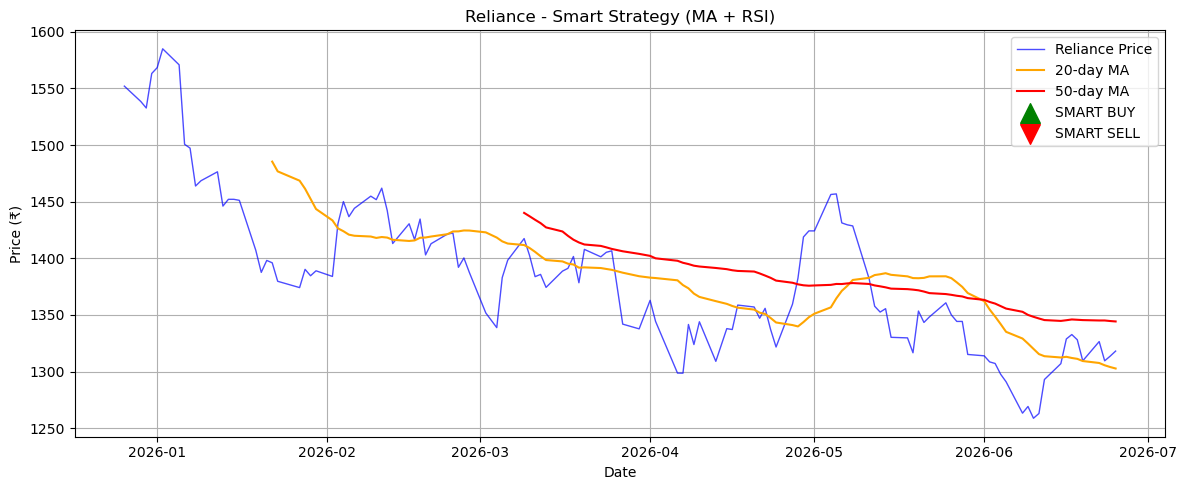


📈 SMART BUY signals:
Empty DataFrame
Columns: [(Close, RELIANCE.NS)]
Index: []

📉 SMART SELL signals:
Empty DataFrame
Columns: [(Close, RELIANCE.NS)]
Index: []


In [11]:
# Smart Strategy - MA Crossover + RSI Filter
stock['Smart_Signal'] = 0

for i in range(len(stock)):
    ma20 = stock['MA20'].iloc[i].item()
    ma50 = stock['MA50'].iloc[i].item()
    rsi = stock['RSI'].iloc[i].item()
    
    # BUY only if MA20 > MA50 AND RSI < 55 (not overbought)
    if ma20 > ma50 and rsi < 55:
        stock.iloc[i, stock.columns.get_loc('Smart_Signal')] = 1
    
    # SELL only if MA20 < MA50 AND RSI > 45 (not oversold)
    elif ma20 < ma50 and rsi > 45:
        stock.iloc[i, stock.columns.get_loc('Smart_Signal')] = -1

stock['Smart_Position'] = stock['Smart_Signal'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], label='Reliance Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock['MA50'], label='50-day MA', color='red', linewidth=1.5)

# Smart Buy signals
smart_buy = stock[stock['Smart_Position'] == 2]
plt.scatter(smart_buy.index, smart_buy['Close'], 
            marker='^', color='green', label='SMART BUY', s=200, zorder=5)

# Smart Sell signals
smart_sell = stock[stock['Smart_Position'] == -2]
plt.scatter(smart_sell.index, smart_sell['Close'], 
            marker='v', color='red', label='SMART SELL', s=200, zorder=5)

plt.title('Reliance - Smart Strategy (MA + RSI)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📈 SMART BUY signals:")
print(smart_buy[['Close']].to_string())
print("\n📉 SMART SELL signals:")
print(smart_sell[['Close']].to_string())

[*********************100%***********************]  1 of 1 completed


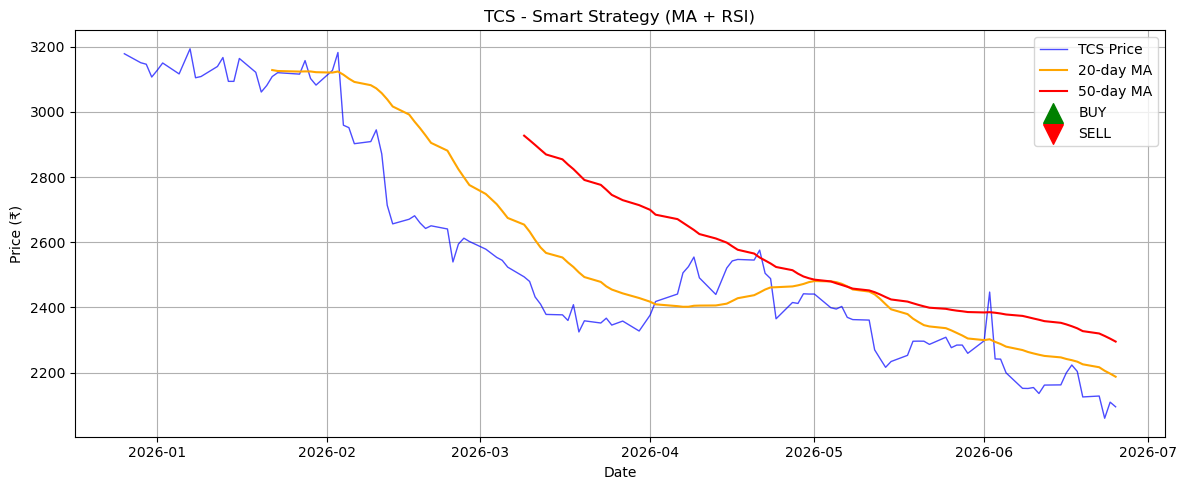


📈 BUY signals:
Empty DataFrame
Columns: [(Close, TCS.NS)]
Index: []

📉 SELL signals:
Empty DataFrame
Columns: [(Close, TCS.NS)]
Index: []


In [12]:
# Try TCS - more volatile, better for this strategy
stock2 = yf.download("TCS.NS", period="6mo", interval="1d")

stock2['MA20'] = stock2['Close'].rolling(window=20).mean()
stock2['MA50'] = stock2['Close'].rolling(window=50).mean()
stock2['RSI'] = calculate_rsi(stock2['Close'])
stock2['Signal'] = 0
stock2['Position'] = 0

for i in range(len(stock2)):
    ma20 = stock2['MA20'].iloc[i].item()
    ma50 = stock2['MA50'].iloc[i].item()
    rsi = stock2['RSI'].iloc[i].item()
    
    if ma20 > ma50 and rsi < 55:
        stock2.iloc[i, stock2.columns.get_loc('Signal')] = 1
    elif ma20 < ma50 and rsi > 45:
        stock2.iloc[i, stock2.columns.get_loc('Signal')] = -1

stock2['Position'] = stock2['Signal'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock2['Close'], label='TCS Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock2['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock2['MA50'], label='50-day MA', color='red', linewidth=1.5)

buy2 = stock2[stock2['Position'] == 2]
sell2 = stock2[stock2['Position'] == -2]

plt.scatter(buy2.index, buy2['Close'], marker='^', color='green', 
            label='BUY', s=200, zorder=5)
plt.scatter(sell2.index, sell2['Close'], marker='v', color='red', 
            label='SELL', s=200, zorder=5)

plt.title('TCS - Smart Strategy (MA + RSI)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📈 BUY signals:")
print(buy2[['Close']].to_string())
print("\n📉 SELL signals:")
print(sell2[['Close']].to_string())

In [13]:
# Test on multiple stocks - find one with signals
tickers = ["HDFCBANK.NS", "TATAMOTORS.NS", "ADANIENT.NS", "SUNPHARMA.NS"]

for ticker in tickers:
    s = yf.download(ticker, period="6mo", interval="1d", progress=False)
    s['MA20'] = s['Close'].rolling(20).mean()
    s['MA50'] = s['Close'].rolling(50).mean()
    s['Signal'] = 0
    
    for i in range(len(s)):
        try:
            ma20 = s['MA20'].iloc[i].item()
            ma50 = s['MA50'].iloc[i].item()
            if ma20 > ma50:
                s.iloc[i, s.columns.get_loc('Signal')] = 1
            elif ma20 < ma50:
                s.iloc[i, s.columns.get_loc('Signal')] = -1
        except:
            pass
    
    s['Position'] = s['Signal'].diff()
    buys = len(s[s['Position'] == 2])
    sells = len(s[s['Position'] == -2])
    
    start = s['Close'].iloc[0].item()
    end = s['Close'].iloc[-1].item()
    change = ((end - start) / start) * 100
    
    print(f"{ticker:20} | Change: {change:+.1f}% | BUY signals: {buys} | SELL signals: {sells}")

HDFCBANK.NS          | Change: -18.4% | BUY signals: 0 | SELL signals: 0


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")


IndexError: single positional indexer is out-of-bounds

In [14]:
# Fixed - skip empty/delisted stocks
tickers = ["HDFCBANK.NS", "ADANIENT.NS", "SUNPHARMA.NS", "WIPRO.NS", "BAJFINANCE.NS"]

for ticker in tickers:
    try:
        s = yf.download(ticker, period="6mo", interval="1d", progress=False)
        
        # Skip if empty or too little data
        if len(s) < 60:
            print(f"{ticker:20} | Skipped - not enough data")
            continue
            
        s['MA20'] = s['Close'].rolling(20).mean()
        s['MA50'] = s['Close'].rolling(50).mean()
        s['Signal'] = 0
        
        for i in range(len(s)):
            try:
                ma20 = s['MA20'].iloc[i].item()
                ma50 = s['MA50'].iloc[i].item()
                if ma20 > ma50:
                    s.iloc[i, s.columns.get_loc('Signal')] = 1
                elif ma20 < ma50:
                    s.iloc[i, s.columns.get_loc('Signal')] = -1
            except:
                pass
        
        s['Position'] = s['Signal'].diff()
        buys = len(s[s['Position'] == 2])
        sells = len(s[s['Position'] == -2])
        
        start = s['Close'].iloc[0].item()
        end = s['Close'].iloc[-1].item()
        change = ((end - start) / start) * 100
        
        print(f"{ticker:20} | Change: {change:+.1f}% | BUY signals: {buys} | SELL signals: {sells}")
    
    except Exception as e:
        print(f"{ticker:20} | Error - skipped")

HDFCBANK.NS          | Change: -18.4% | BUY signals: 0 | SELL signals: 0
ADANIENT.NS          | Change: +36.3% | BUY signals: 1 | SELL signals: 1
SUNPHARMA.NS         | Change: +9.0% | BUY signals: 1 | SELL signals: 1
WIPRO.NS             | Change: -32.6% | BUY signals: 1 | SELL signals: 1
BAJFINANCE.NS        | Change: -2.0% | BUY signals: 1 | SELL signals: 2


In [15]:
# Backtest on ADANIENT
stock3 = yf.download("ADANIENT.NS", period="6mo", interval="1d", progress=False)

stock3['MA20'] = stock3['Close'].rolling(20).mean()
stock3['MA50'] = stock3['Close'].rolling(50).mean()
stock3['RSI'] = calculate_rsi(stock3['Close'])
stock3['Signal'] = 0

for i in range(len(stock3)):
    try:
        ma20 = stock3['MA20'].iloc[i].item()
        ma50 = stock3['MA50'].iloc[i].item()
        rsi = stock3['RSI'].iloc[i].item()
        if ma20 > ma50 and rsi < 55:
            stock3.iloc[i, stock3.columns.get_loc('Signal')] = 1
        elif ma20 < ma50 and rsi > 45:
            stock3.iloc[i, stock3.columns.get_loc('Signal')] = -1
    except:
        pass

stock3['Position'] = stock3['Signal'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock3['Close'], label='Adani Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock3['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock3['MA50'], label='50-day MA', color='red', linewidth=1.5)

buy3 = stock3[stock3['Position'] == 2]
sell3 = stock3[stock3['Position'] == -2]

plt.scatter(buy3.index, buy3['Close'], marker='^', color='green',
            label='BUY', s=200, zorder=5)
plt.scatter(sell3.index, sell3['Close'], marker='v', color='red',
            label='SELL', s=200, zorder=5)

plt.title('Adani Enterprise - Smart Strategy (MA + RSI)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Backtest numbers
capital = 100000
shares = 0
trades = []

for date, row in stock3.iterrows():
    position = row['Position'].item()
    close_price = row['Close'].item()
    
    if position == 2 and capital > 0:
        shares = capital // close_price
        capital -= shares * close_price
        trades.append({'Date': date, 'Action': 'BUY',
                      'Price': close_price, 'Shares': shares})
    elif position == -2 and shares > 0:

SyntaxError: incomplete input (2844152217.py, line 59)

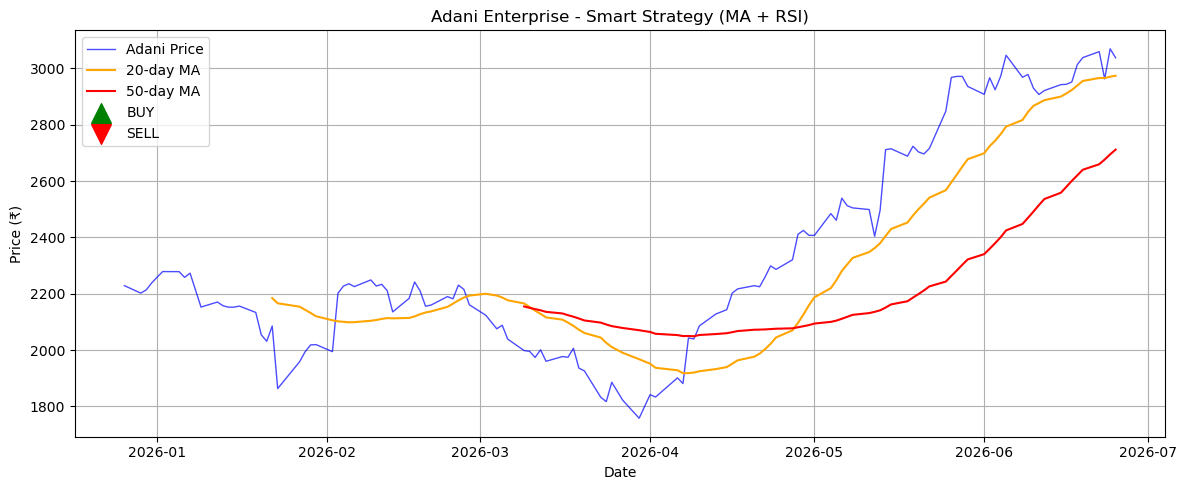


Starting Capital: ₹1,00,000
Final Value:      ₹100,000
Profit/Loss:      ₹0
Return:           0.00%

Trades:


In [16]:
# Backtest on ADANIENT
stock3 = yf.download("ADANIENT.NS", period="6mo", interval="1d", progress=False)

stock3['MA20'] = stock3['Close'].rolling(20).mean()
stock3['MA50'] = stock3['Close'].rolling(50).mean()
stock3['RSI'] = calculate_rsi(stock3['Close'])
stock3['Signal'] = 0

for i in range(len(stock3)):
    try:
        ma20 = stock3['MA20'].iloc[i].item()
        ma50 = stock3['MA50'].iloc[i].item()
        rsi = stock3['RSI'].iloc[i].item()
        if ma20 > ma50 and rsi < 55:
            stock3.iloc[i, stock3.columns.get_loc('Signal')] = 1
        elif ma20 < ma50 and rsi > 45:
            stock3.iloc[i, stock3.columns.get_loc('Signal')] = -1
    except:
        pass

stock3['Position'] = stock3['Signal'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock3['Close'], label='Adani Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock3['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock3['MA50'], label='50-day MA', color='red', linewidth=1.5)

buy3 = stock3[stock3['Position'] == 2]
sell3 = stock3[stock3['Position'] == -2]

plt.scatter(buy3.index, buy3['Close'], marker='^', color='green',
            label='BUY', s=200, zorder=5)
plt.scatter(sell3.index, sell3['Close'], marker='v', color='red',
            label='SELL', s=200, zorder=5)

plt.title('Adani Enterprise - Smart Strategy (MA + RSI)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Backtest numbers
capital = 100000
shares = 0
trades = []

for date, row in stock3.iterrows():
    position = row['Position'].item()
    close_price = row['Close'].item()
    
    if position == 2 and capital > 0:
        shares = capital // close_price
        capital -= shares * close_price
        trades.append({'Date': date, 'Action': 'BUY',
                      'Price': close_price, 'Shares': shares})
    elif position == -2 and shares > 0:
        capital += shares * close_price
        trades.append({'Date': date, 'Action': 'SELL',
                      'Price': close_price, 'Shares': shares})
        shares = 0

final_close = stock3['Close'].iloc[-1].item()
final_value = capital + (shares * final_close)

print(f"\nStarting Capital: ₹1,00,000")
print(f"Final Value:      ₹{final_value:,.0f}")
print(f"Profit/Loss:      ₹{final_value - 100000:,.0f}")
print(f"Return:           {((final_value - 100000)/100000)*100:.2f}%")
print(f"\nTrades:")
for t in trades:
    print(f"{t['Date'].date()} | {t['Action']} | ₹{t['Price']:.0f} | {t['Shares']:.0f} shares")

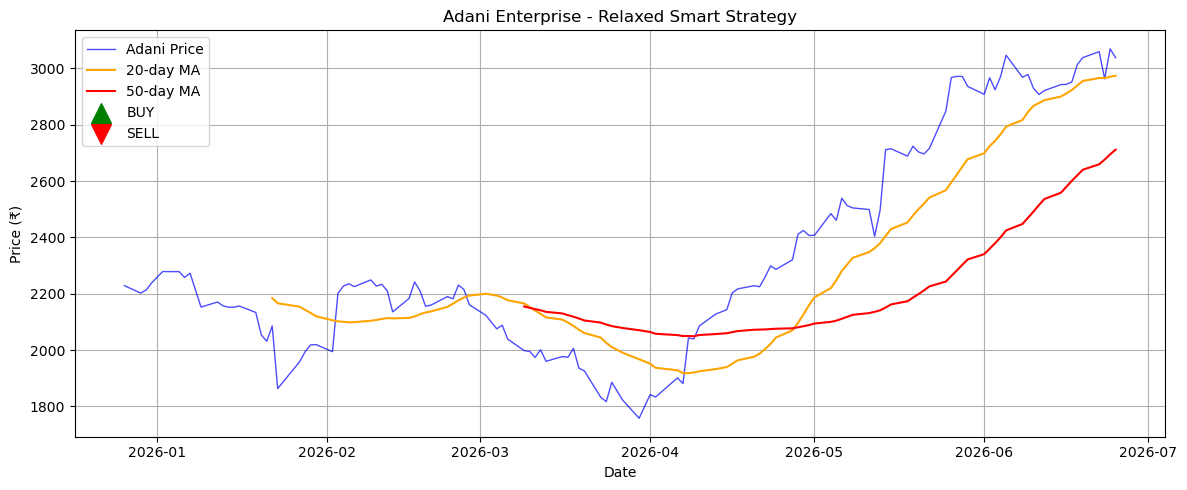


Starting Capital: ₹1,00,000
Final Value:      ₹100,000
Profit/Loss:      ₹0
Return:           0.00%

Trades:


In [17]:
# Backtest on ADANIENT - Relaxed RSI filter
capital = 100000
shares = 0
trades = []

# Recalculate signals with relaxed RSI
stock3['Signal2'] = 0

for i in range(len(stock3)):
    try:
        ma20 = stock3['MA20'].iloc[i].item()
        ma50 = stock3['MA50'].iloc[i].item()
        rsi = stock3['RSI'].iloc[i].item()
        
        # Relaxed - BUY if MA20 > MA50 AND RSI < 70 (not extremely overbought)
        if ma20 > ma50 and rsi < 70:
            stock3.iloc[i, stock3.columns.get_loc('Signal2')] = 1
        
        # SELL if MA20 < MA50 AND RSI > 30 (not extremely oversold)
        elif ma20 < ma50 and rsi > 30:
            stock3.iloc[i, stock3.columns.get_loc('Signal2')] = -1
    except:
        pass

stock3['Position2'] = stock3['Signal2'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(stock3['Close'], label='Adani Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock3['MA20'], label='20-day MA', color='orange', linewidth=1.5)
plt.plot(stock3['MA50'], label='50-day MA', color='red', linewidth=1.5)

buy3 = stock3[stock3['Position2'] == 2]
sell3 = stock3[stock3['Position2'] == -2]

plt.scatter(buy3.index, buy3['Close'], marker='^', color='green',
            label='BUY', s=200, zorder=5)
plt.scatter(sell3.index, sell3['Close'], marker='v', color='red',
            label='SELL', s=200, zorder=5)

plt.title('Adani Enterprise - Relaxed Smart Strategy')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Run backtest
for date, row in stock3.iterrows():
    position = row['Position2'].item()
    close_price = row['Close'].item()
    
    if position == 2 and capital > 0:
        shares = capital // close_price
        capital -= shares * close_price
        trades.append({'Date': date, 'Action': 'BUY',
                      'Price': close_price, 'Shares': shares})
    elif position == -2 and shares > 0:
        capital += shares * close_price
        trades.append({'Date': date, 'Action': 'SELL',
                      'Price': close_price, 'Shares': shares})
        shares = 0

final_close = stock3['Close'].iloc[-1].item()
final_value = capital + (shares * final_close)

print(f"\nStarting Capital: ₹1,00,000")
print(f"Final Value:      ₹{final_value:,.0f}")
print(f"Profit/Loss:      ₹{final_value - 100000:,.0f}")
print(f"Return:           {((final_value - 100000)/100000)*100:.2f}%")
print(f"\nTrades:")
for t in trades:
    print(f"{t['Date'].date()} | {t['Action']} | ₹{t['Price']:.0f} | {t['Shares']:.0f} shares")

In [18]:
# Debug - see what's actually in the data
print("MA20 > MA50 crossover dates:")
crossovers = stock3[stock3['Position2'] != 0][['Close', 'MA20', 'MA50', 'RSI', 'Signal2', 'Position2']]
print(crossovers.to_string())

print("\nSample of Signal2 values:")
print(stock3['Signal2'].value_counts())

print("\nSample of Position2 values:")
print(stock3['Position2'].value_counts())

print("\nFirst 5 rows where MA20 > MA50:")
mask = stock3['MA20'] > stock3['MA50']
print(stock3[mask][['Close','MA20','MA50','RSI']].head())

MA20 > MA50 crossover dates:
Price             Close         MA20         MA50        RSI Signal2 Position2
Ticker      ADANIENT.NS                                                       
Date                                                                          
2025-12-26  2228.903320          NaN          NaN        NaN       0       NaN
2026-03-09  1998.306519  2165.571765  2154.796575  31.211971       1       1.0
2026-03-11  1973.817383  2140.218097  2145.562705  22.365039       0      -1.0
2026-03-12  2001.105225  2128.603290  2141.310605  30.696285      -1      -1.0
2026-03-13  1960.223511  2116.073889  2135.741096  27.177111       0       1.0
2026-04-01  1841.676514  1951.627405  2064.360999  37.393568      -1      -1.0
2026-04-28  2411.321777  2096.437659  2080.991565  96.607427       0       1.0
2026-05-12  2404.125000  2361.958911  2135.821038  63.836702       1       1.0
2026-05-14  2711.687500  2405.079626  2151.070217  77.336401       0      -1.0
2026-05-22  2716.085693

In [19]:
# Clean simple backtest - pure MA crossover only
capital = 100000
shares = 0
trades = []

# Fresh clean signal
stock3['FinalSignal'] = 0
prev_state = 0

for i in range(1, len(stock3)):
    try:
        ma20 = stock3['MA20'].iloc[i].item()
        ma50 = stock3['MA50'].iloc[i].item()
        prev_ma20 = stock3['MA20'].iloc[i-1].item()
        prev_ma50 = stock3['MA50'].iloc[i-1].item()
        close = stock3['Close'].iloc[i].item()

        # Real crossover - MA20 crosses ABOVE MA50
        if prev_ma20 <= prev_ma50 and ma20 > ma50:
            shares_to_buy = capital // close
            if shares_to_buy > 0 and capital > 0:
                shares = shares_to_buy
                capital -= shares * close
                trades.append({'Date': stock3.index[i], 
                              'Action': 'BUY', 'Price': close, 'Shares': shares})

        # Real crossover - MA20 crosses BELOW MA50
        elif prev_ma20 >= prev_ma50 and ma20 < ma50:
            if shares > 0:
                capital += shares * close
                trades.append({'Date': stock3.index[i], 
                              'Action': 'SELL', 'Price': close, 'Shares': shares})
                shares = 0
    except:
        pass

final_close = stock3['Close'].iloc[-1].item()
final_value = capital + (shares * final_close)

print(f"Starting Capital: ₹1,00,000")
print(f"Final Value:      ₹{final_value:,.0f}")
print(f"Profit/Loss:      ₹{final_value - 100000:,.0f}")
print(f"Return:           {((final_value - 100000)/100000)*100:.2f}%")
print(f"\nTrades:")
for t in trades:
    print(f"{t['Date'].date()} | {t['Action']} | ₹{t['Price']:.0f} | {t['Shares']:.0f} shares")

Starting Capital: ₹1,00,000
Final Value:      ₹125,694
Profit/Loss:      ₹25,694
Return:           25.69%

Trades:
2026-04-28 | BUY | ₹2411 | 41 shares


In [20]:
import os
print(os.getcwd())

C:\Users\amogh.WALLFLOWER
